# Загрязнение воздуха и продолжительность жизни в регионах России (2015)
**Эконометрический проект: EDA и базовые IV-проверки**

Кросс-секция: 1 строка = 1 субъект РФ за 2015 год. Зависимая переменная — ожидаемая продолжительность жизни (`life_expectancy`). Основная объясняющая переменная — лог выбросов загрязняющих веществ на душу (`ln_emissions_h1_pc`).

## 1. Постановка задачи

**Исследовательский вопрос.** Связано ли более высокое атмосферное загрязнение с более низкой ожидаемой продолжительностью жизни в регионах России?

**Рабочая гипотеза.** Более высокий уровень выбросов на душу связан с более низкой `life_expectancy`.

**Ограничение интерпретации.** Даже при использовании инструмента причинная интерпретация должна оставаться осторожной: кросс-секция небольшая, источники неоднородны, а доступные IV не идеальны.

**Замечание по статистическим тестам.** Гипотезы проекта в основном направленные по знаку, но стандартная отчётность ниже использует двусторонние p-value.

In [1]:
# Импорты и настройка отображения
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.iv import IV2SLS

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})

df = pd.read_csv('validated_dataset_extended.csv')
print(f'Загружено: validated_dataset_extended.csv  ->  shape = {df.shape}')

Загружено: validated_dataset_extended.csv  ->  shape = (85, 34)


## 2. Обзор данных

In [2]:
print(f'Размер датасета : {df.shape[0]} регионов × {df.shape[1]} колонок')
print(f'Год             : 2015 (employment-переменные на 2017 — earliest available)')
print()
print('Типы данных:')
print(df.dtypes.to_string())

miss = df.isna().sum()
miss = miss[miss > 0]
print()
if len(miss):
    print('Пропуски:')
    print(miss.to_string())
else:
    print('Пропусков в датасете нет.')

Размер датасета : 85 регионов × 34 колонок
Год             : 2015 (employment-переменные на 2017 — earliest available)

Типы данных:
region                      object
year                         int64
population_avg             float64
life_expectancy            float64
visits_per_capita          float64
urban_share                float64
grp_total                  float64
age_struct_share           float64
emissions_h1               float64
emissions_fuel             float64
industrial_index           float64
grp_pc                     float64
emissions_h1_pc            float64
emissions_fuel_pc          float64
ln_grp_pc                  float64
ln_emissions_h1_pc         float64
ln_emissions_fuel_pc       float64
ln_population_avg          float64
emp_mining                 float64
emp_manufacturing          float64
emp_energy                 float64
emp_metallurgy             float64
emp_chemicals              float64
emp_construction           float64
emp_mining_pc              

**Комментарий по выборке.** Финальная кросс-секция содержит **85 субъектов РФ**. В preprocessing отдельно проверена проблема Архангельской / Тюменской областей и автономных округов: для областей используются строки `...(кроме ...)`, а НАО, ХМАО и ЯНАО остаются отдельными субъектами, так что двойного счёта в итоговом датасете нет. Год наблюдения — 2015 для всех переменных, кроме показателей структуры занятости, которые в источнике начинаются с 2017 года. Переменная `region` используется только как идентификатор наблюдения, а не как категориальный регрессор.

## 3. Переменные модели

**Предпочитаемая baseline-спецификация**

| Роль | Переменная | Описание |
|---|---|---|
| Зависимая (Y) | `life_expectancy` | Ожидаемая продолжительность жизни при рождении, годы |
| Эндогенный регрессор | `ln_emissions_h1_pc` | log выбросов загрязняющих веществ на душу |
| Инструмент (IV) | `ln_emp_mining_pc` | log занятости в добыче на душу |
| Контроль | `ln_grp_pc` | log ВРП на душу |
| Контроль | `urban_share` | Доля городского населения |
| Контроль | `ln_population_avg` | log численности населения |

**Переменные вне baseline**

- `age_struct_share` используется только в robustness-check: демографическая структура может частично отражать накопленные различия в смертности, поэтому интерпретировать её как чисто экзогенный контроль не стоит.
- `visits_per_capita` не включается в preferred specification: обращаемость в медучреждения может быть эндогенна по отношению к здоровью, а сам прокси измерен шумно.
- `ln_emp_energy_pc` и `ln_emissions_fuel_pc` рассматриваются только как альтернативные инструменты для сравнения, а не как preferred IV.

In [3]:
# Определяем группы переменных
DV = 'life_expectancy'
ENDO = 'ln_emissions_h1_pc'
IV = 'ln_emp_mining_pc'
ALT_IVS = ['ln_emp_energy_pc', 'ln_emissions_fuel_pc']
BASE_CONTROLS = ['ln_grp_pc', 'urban_share', 'ln_population_avg']
ROBUST_CONTROLS = BASE_CONTROLS + ['age_struct_share']
MAIN_VARS = [DV, ENDO, IV] + BASE_CONTROLS
DESC_VARS = MAIN_VARS + ['age_struct_share']

data_base = df[['region', DV, ENDO, IV] + ALT_IVS + BASE_CONTROLS].dropna().copy()
data_age = df[['region', DV, ENDO, IV] + ALT_IVS + ROBUST_CONTROLS].dropna().copy()

print(f'DV                : {DV}')
print(f'Endogenous        : {ENDO}')
print(f'Preferred IV      : {IV}')
print(f'Baseline controls : {BASE_CONTROLS}')
print(f'Age robustness    : {ROBUST_CONTROLS}')
print()
print(f'Эффективная выборка baseline        : N = {len(data_base)}')
print(f'Эффективная выборка age-robustness  : N = {len(data_age)}')

DV                : life_expectancy
Endogenous        : ln_emissions_h1_pc
Preferred IV      : ln_emp_mining_pc
Baseline controls : ['ln_grp_pc', 'urban_share', 'ln_population_avg']
Age robustness    : ['ln_grp_pc', 'urban_share', 'ln_population_avg', 'age_struct_share']

Эффективная выборка baseline        : N = 85
Эффективная выборка age-robustness  : N = 85


## 4. Дескриптивная статистика

In [4]:
desc = df[DESC_VARS].agg(['mean', 'std', 'min', 'median', 'max']).T
desc.columns = ['Среднее', 'Ст.откл.', 'Мин', 'Медиана', 'Макс']
desc.round(3)

,Среднее,Ст.откл.,Мин,Медиана,Макс
life_expectancy,70.5540,2.3930,63.1400,70.3900,78.4700
ln_emissions_h1_pc,-10.3360,1.3930,-14.5160,-10.2620,-6.9960
ln_emp_mining_pc,-5.5710,1.6550,-8.7340,-5.9030,-1.5260
ln_grp_pc,5.8340,0.6720,4.6830,5.7690,8.5870
urban_share,70.0860,13.2470,29.9000,71.3000,100.0000
ln_population_avg,13.9600,0.9710,10.6550,13.9890,16.3230
age_struct_share,58.0470,2.1450,50.9000,57.7000,64.9000


## 5. Визуальный EDA

### 5.1 Распределения основных переменных

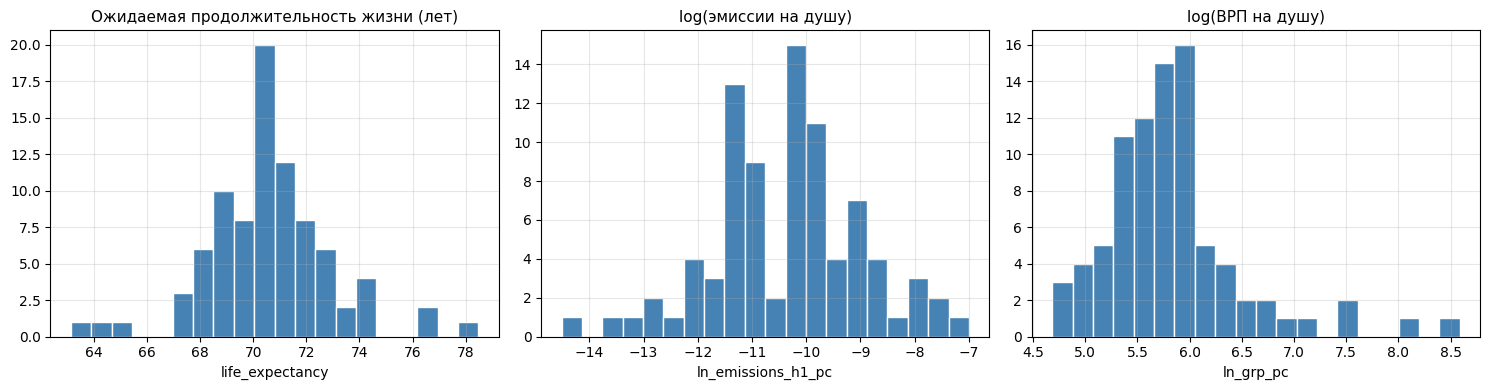

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c, title in zip(
    axes,
    ['life_expectancy', 'ln_emissions_h1_pc', 'ln_grp_pc'],
    ['Ожидаемая продолжительность жизни (лет)',
     'log(эмиссии на душу)',
     'log(ВРП на душу)']):
    df[c].dropna().hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(c)
plt.tight_layout()
plt.show()

**Интерпретация гистограмм.**
- `life_expectancy` распределена приблизительно симметрично вокруг 70 лет (диапазон 63-78). Линейная форма в модели обоснована.
- `ln_emissions_h1_pc` после логарифмирования имеет почти симметричное распределение (skew ≈ 0). В исходной шкале — асимметрия (skew ≈ 3.6) из-за нескольких сильно загрязняющих регионов.
- `ln_grp_pc` тоже близок к симметричному после log; в исходной шкале распределение тяжёлохвостое из-за нефтегазовых регионов (НАО, ЯНАО, ХМАО, Сахалин).

### 5.2 Связи между переменными

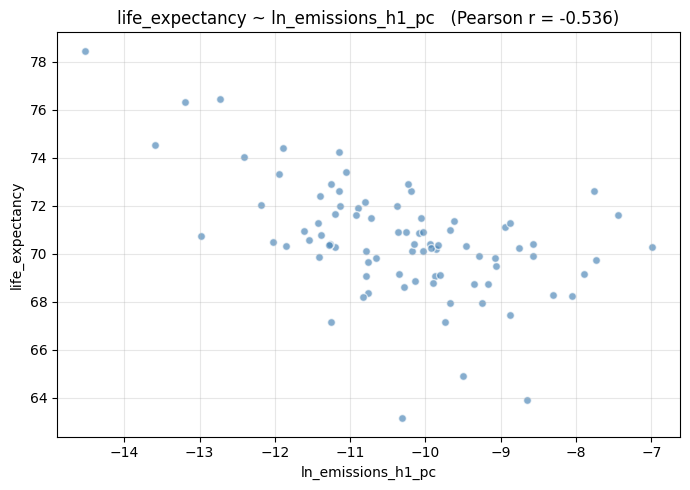

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['ln_emissions_h1_pc'], df['life_expectancy'], alpha=0.65, s=32, color='steelblue', edgecolor='white')
r = df[['ln_emissions_h1_pc', 'life_expectancy']].corr().iloc[0, 1]
ax.set_xlabel('ln_emissions_h1_pc')
ax.set_ylabel('life_expectancy')
ax.set_title(f'life_expectancy ~ ln_emissions_h1_pc   (Pearson r = {r:+.3f})')
plt.tight_layout(); plt.show()

**Наблюдение.** Связь между логарифмом эмиссий на душу и продолжительностью жизни **отрицательная** (r ≈ −0.52): более загрязнённые регионы в среднем имеют более низкую `life_expectancy`. Это согласуется с рабочей гипотезой, но само по себе ещё не даёт причинной интерпретации, потому что корреляция не контролирует возможные конфаундеры.

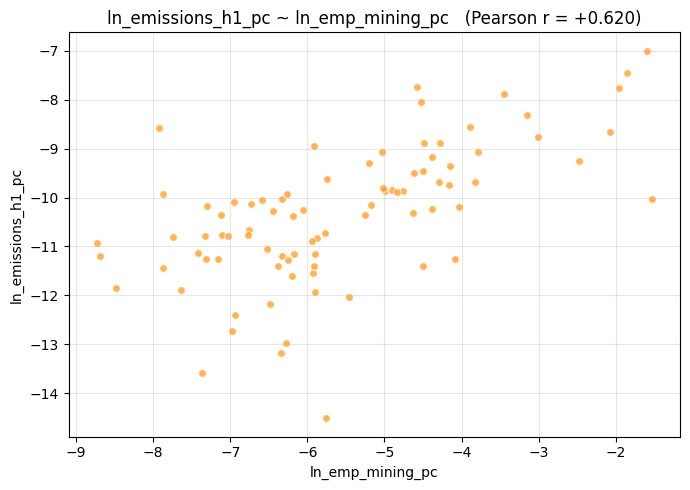

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['ln_emp_mining_pc'], df['ln_emissions_h1_pc'], alpha=0.65, s=32, color='darkorange', edgecolor='white')
r = df[['ln_emp_mining_pc', 'ln_emissions_h1_pc']].corr().iloc[0, 1]
ax.set_xlabel('ln_emp_mining_pc')
ax.set_ylabel('ln_emissions_h1_pc')
ax.set_title(f'ln_emissions_h1_pc ~ ln_emp_mining_pc   (Pearson r = {r:+.3f})')
plt.tight_layout(); plt.show()

**Наблюдение.** Положительная связь между занятостью в добыче и эмиссиями (r ≈ +0.65) поддерживает relevance предпочитаемого инструмента. Однако окончательный вывод о силе инструмента удобнее делать по first-stage регрессии: в небольшой cross-section даже заметная безусловная корреляция не гарантирует сильный IV.

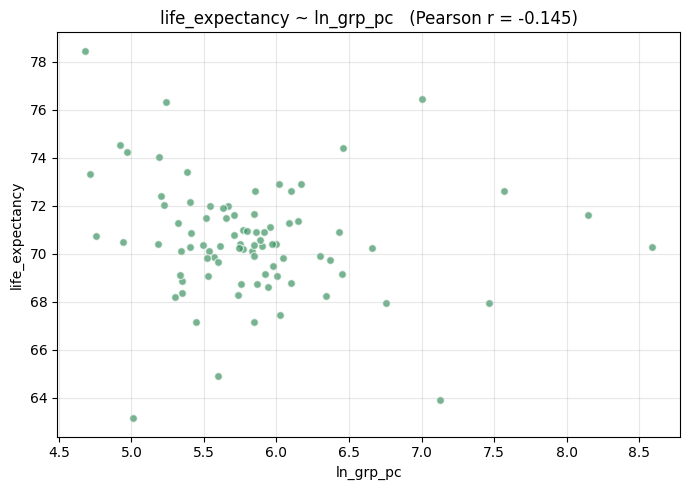

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['ln_grp_pc'], df['life_expectancy'], alpha=0.65, s=32, color='seagreen', edgecolor='white')
r = df[['ln_grp_pc', 'life_expectancy']].corr().iloc[0, 1]
ax.set_xlabel('ln_grp_pc')
ax.set_ylabel('life_expectancy')
ax.set_title(f'life_expectancy ~ ln_grp_pc   (Pearson r = {r:+.3f})')
plt.tight_layout(); plt.show()

**Наблюдение.** Безусловная корреляция между log ВРП на душу и продолжительностью жизни слабо отрицательная (r ≈ −0.13). Это **парадокс российских нефтегазовых регионов**: высокий ВРП на душу часто соседствует со сложными климатическими условиями и низкой продолжительностью жизни (Чукотка, ЯНАО, НАО). После контроля климатических / демографических факторов знак ожидаемо станет нейтральным или положительным.

## 6. Корреляционная матрица

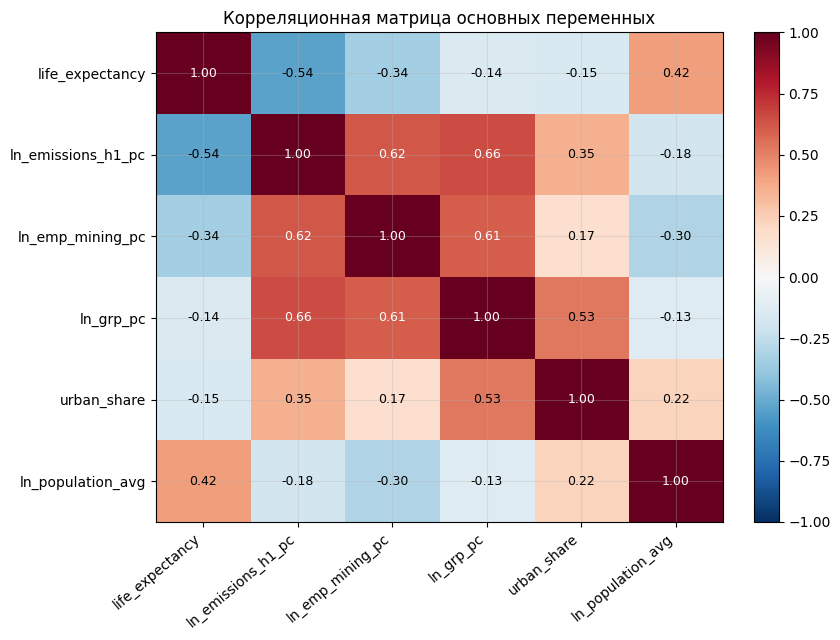

,life_expectancy,ln_emissions_h1_pc,ln_emp_mining_pc,ln_grp_pc,urban_share,ln_population_avg
life_expectancy,1.0000,-0.5360,-0.3410,-0.1450,-0.1520,0.4190
ln_emissions_h1_pc,-0.5360,1.0000,0.6200,0.6560,0.3530,-0.1800
ln_emp_mining_pc,-0.3410,0.6200,1.0000,0.6070,0.1680,-0.3000
ln_grp_pc,-0.1450,0.6560,0.6070,1.0000,0.5250,-0.1320
urban_share,-0.1520,0.3530,0.1680,0.5250,1.0000,0.2190
ln_population_avg,0.4190,-0.1800,-0.3000,-0.1320,0.2190,1.0000


In [9]:
corr = df[MAIN_VARS].corr().round(3)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=40, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title('Корреляционная матрица основных переменных')
plt.tight_layout(); plt.show()

corr

**Содержательная интерпретация.**

- corr(`life_expectancy`, `ln_emissions_h1_pc`) отрицательна, что соответствует основной гипотезе.
- corr(`ln_emissions_h1_pc`, `ln_emp_mining_pc`) положительна и поддерживает relevance предпочитаемого инструмента.
- `ln_grp_pc` и `ln_population_avg` помогают отделить экологический канал от различий по масштабу и уровню экономического развития.
- `age_struct_share` сознательно вынесена из baseline-корреляционной матрицы: ниже она рассматривается только как осторожный robustness-control.

## 7. Заметные выбросы (без удаления)

In [10]:
WATCH = [
    'Ненецкий автономный округ (Архангельская область)',
    'Ямало-Ненецкий автономный округ (Тюменская область)',
    'Ханты-Мансийский автономный округ - Югра (Тюменская область)',
    'Севастополь',
    'Чукотский автономный округ',
]
present = [w for w in WATCH if w in df['region'].values]
cols_show = [DV, ENDO, IV, 'ln_grp_pc', 'urban_share', 'age_struct_share', 'industrial_index']
df.set_index('region').loc[present, cols_show].round(3)

,life_expectancy,ln_emissions_h1_pc,ln_emp_mining_pc,ln_grp_pc,urban_share,age_struct_share,industrial_index
region,,,,,,,
Ненецкий автономный округ (Архангельская область),70.2900,-6.9960,-1.5900,8.5870,71.7000,55.0000,110.2000
Ямало-Ненецкий автономный округ (Тюменская область),71.6100,-7.4430,-1.8560,8.1460,84.9000,64.7000,104.5000
Ханты-Мансийский автономный округ - Югра (Тюменская область),72.6200,-7.7640,-1.9590,7.5710,91.9000,61.6000,97.5000
Севастополь,70.7600,-12.9850,-6.2830,4.7570,92.4000,57.2000,372.9000
Чукотский автономный округ,63.9100,-8.6560,-2.0690,7.1300,67.2000,64.9000,101.9000


**Замечания по выбросам.**

- **НАО, ЯНАО, ХМАО, Чукотка** остаются содержательно важными регионами: именно они формируют большую часть variation в добыче, доходах и выбросах.
- В baseline-спецификации наблюдения **не удаляются**. Диагностика ниже только помечает точки с высоким leverage / Cook's D.
- Отдельно показана robustness-проверка без наиболее влиятельного наблюдения, чтобы убедиться, что результат не держится на одной точке.

## 8. Итоговые выводы EDA

**Качество данных.** Финальная выборка содержит 85 субъектов РФ без дублей `(region, year)`. После отдельной проверки Архангельской и Тюменской областей с AO в датасете нет двойного счёта регионов.

**Экономическая картина.** Выбросы на душу, добыча и доходы особенно велики в добывающих северных регионах. Поэтому простую OLS-связь загрязнения и `life_expectancy` полезно дополнять IV-подходом, но интерпретировать его всё равно нужно осторожно.

**Спецификация.** Preferred baseline не включает `age_struct_share` и `visits_per_capita`; первая переменная трактуется осторожно и используется только как robustness-control, вторая исключается из preferred specification как потенциально эндогенная и шумная.

---
## 9. Спецификация и диагностические проверки

Ниже фиксируется preferred baseline-спецификация, а затем показываются более осторожные проверки: first-stage, reduced form, OLS/2SLS, сравнение альтернативных IV, интерпретация Wu-Hausman и чувствительность к влиятельным наблюдениям.

### 9.1 Финальная выборка

In [11]:
print(f'Всего строк в датасете         : {len(df)}')
print(f'Дубли по region               : {df["region"].duplicated().sum()}')
print(f'Пропуски в baseline-переменных: {df[[DV, ENDO, IV] + ALT_IVS + BASE_CONTROLS].isna().sum().sum()}')
print('Не-конечные значения в логах  :')
for c in [ENDO, IV] + ALT_IVS + [v for v in BASE_CONTROLS if v.startswith('ln_')]:
    print(f'  {c}: {(~np.isfinite(df[c])).sum()}')

print(f'\nBaseline sample              : N = {len(data_base)}')
print(f'Age-robustness sample        : N = {len(data_age)}')


Всего строк в датасете         : 85
Дубли по region               : 0
Пропуски в baseline-переменных: 0
Не-конечные значения в логах  :
  ln_emissions_h1_pc: 0
  ln_emp_mining_pc: 0
  ln_emp_energy_pc: 0
  ln_emissions_fuel_pc: 0
  ln_grp_pc: 0
  ln_population_avg: 0

Baseline sample              : N = 85
Age-robustness sample        : N = 85


### 9.2 First-stage: релевантность предпочитаемого IV
Регрессия первого этапа: `ln_emissions_h1_pc ~ ln_emp_mining_pc + ln_grp_pc + urban_share + ln_population_avg`. Ниже показаны сразу две связанные статистики: HC1-robust `sm.OLS.f_test` и partial F из `linearmodels` first stage.

In [12]:
X_fs = sm.add_constant(data_base[[IV] + BASE_CONTROLS])
fs = sm.OLS(data_base[ENDO], X_fs).fit(cov_type='HC1')
ftest = fs.f_test(f'{IV} = 0')

exog_base = sm.add_constant(data_base[BASE_CONTROLS])
iv_base = IV2SLS(
    dependent=data_base[DV],
    exog=exog_base,
    endog=data_base[[ENDO]],
    instruments=data_base[[IV]],
).fit(cov_type='robust', debiased=True)
fs_diag = iv_base.first_stage.diagnostics.loc[ENDO]

print(f'First stage: {ENDO} ~ {IV} + baseline controls   (HC1 / robust)')
print('-' * 80)
print(f'coef on {IV:<22s}: {fs.params[IV]:+.4f}')
print(f't-stat                     : {fs.tvalues[IV]:+.3f}')
print(f'p-value                    : {fs.pvalues[IV]:.4f}')
print(f'R²                         : {fs.rsquared:.4f}')
print(f'sm.OLS robust F-test       : {float(ftest.fvalue):.2f}  (p = {float(ftest.pvalue):.4f})')
print(f'iv.first_stage partial F   : {float(fs_diag["f.stat"]):.2f}  ({fs_diag["f.dist"]}, p = {float(fs_diag["f.pval"]):.4f})')
print()
print(fs.summary().tables[1])

First stage: ln_emissions_h1_pc ~ ln_emp_mining_pc + baseline controls   (HC1 / robust)
--------------------------------------------------------------------------------
coef on ln_emp_mining_pc      : +0.3035
t-stat                     : +2.923
p-value                    : 0.0035
R²                         : 0.5156
sm.OLS robust F-test       : 8.54  (p = 0.0045)
iv.first_stage partial F   : 8.54  (chi2(1), p = 0.0035)

                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -13.0628      3.521     -3.710      0.000     -19.963      -6.162
ln_emp_mining_pc      0.3035      0.104      2.923      0.003       0.100       0.507
ln_grp_pc             0.7797      0.324      2.406      0.016       0.145       1.415
urban_share           0.0111      0.012      0.927      0.354      -0.012       0.034
ln_population_avg    -0.0649      0.139     -0.466      0.642

**Вывод по first-stage.** F-статистика находится **вблизи** правила большого пальца `F ≈ 10`, поэтому её разумно трактовать **эвристически**, а не как жёсткое доказательство сильного инструмента. В терминах undergrad-проекта `ln_emp_mining_pc` выглядит **умеренно сильным**, а не бесспорно сильным IV. Ссылки на пороги Stock-Yogo полезны только как ориентир. Небольшая разница между `sm.OLS.f_test` и `iv.first_stage` нормальна: это близкие, но не полностью идентичные реализации с разным представлением robust covariance и распределения статистики.

### 9.3 Сравнение с альтернативными IV

In [13]:
rows = []
for alt in [IV] + ALT_IVS:
    fs_alt = sm.OLS(data_base[ENDO], sm.add_constant(data_base[[alt] + BASE_CONTROLS])).fit(cov_type='HC1')
    f_alt = fs_alt.f_test(f'{alt} = 0')
    iv_alt = IV2SLS(
        dependent=data_base[DV],
        exog=exog_base,
        endog=data_base[[ENDO]],
        instruments=data_base[[alt]],
    ).fit(cov_type='robust', debiased=True)
    wh = iv_alt.wu_hausman()
    rows.append({
        'instrument': alt,
        'first_stage_F': float(f_alt.fvalue),
        'first_stage_p': float(f_alt.pvalue),
        'corr_with_life_exp': data_base[[alt, DV]].corr().iloc[0, 1],
        'iv_beta': iv_alt.params[ENDO],
        'iv_p': iv_alt.pvalues[ENDO],
        'wu_hausman_p': wh.pval,
    })
alt_compare = pd.DataFrame(rows)
alt_compare.round(4)

,instrument,first_stage_F,first_stage_p,corr_with_life_exp,iv_beta,iv_p,wu_hausman_p
0,ln_emp_mining_pc,8.5414,0.0045,-0.3406,-1.5840,0.0015,0.4119
1,ln_emp_energy_pc,8.5632,0.0045,-0.5367,-2.0811,0.0002,0.0091
2,ln_emissions_fuel_pc,69.2192,0.0000,-0.7268,-2.0553,0.0000,0.0000


**Интерпретация альтернативных IV.**

- `ln_emp_energy_pc` и `ln_emissions_fuel_pc` выглядят **статистически более релевантными**, чем `ln_emp_mining_pc`.
- Но экономически их exclusion restriction слабее. `ln_emissions_fuel_pc` почти механически связан с общим загрязнением, поэтому неудивительно, что first stage у него сильнее.
- `ln_emp_energy_pc` тоже вызывает больше сомнений: занятость в энергетике может быть связана не только с выбросами, но и с доходами, инфраструктурой и индустриальной организацией региона.
- Поэтому эти альтернативы полезны как comparison / robustness, но не как preferred instruments.

### 9.4 Reduced form

In [14]:
X_rf = sm.add_constant(data_base[[IV] + BASE_CONTROLS])
rf = sm.OLS(data_base[DV], X_rf).fit(cov_type='HC1')

print(f'Reduced form: {DV} ~ {IV} + baseline controls   (HC1 robust SE, N = {int(rf.nobs)})')
print('-' * 80)
print(rf.summary().tables[1])
print(f'R² = {rf.rsquared:.4f}   adj R² = {rf.rsquared_adj:.4f}')

Reduced form: life_expectancy ~ ln_emp_mining_pc + baseline controls   (HC1 robust SE, N = 85)
--------------------------------------------------------------------------------
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                51.1695      7.149      7.158      0.000      37.158      65.181
ln_emp_mining_pc     -0.4808      0.171     -2.818      0.005      -0.815      -0.146
ln_grp_pc             1.0559      0.690      1.530      0.126      -0.297       2.409
urban_share          -0.0626      0.025     -2.550      0.011      -0.111      -0.014
ln_population_avg     1.0700      0.293      3.652      0.000       0.496       1.644
R² = 0.3046   adj R² = 0.2698


**Reduced-form reading.** Коэффициент при `ln_emp_mining_pc` имеет ожидаемый **отрицательный** знак: более высокая занятость в добыче связана с более низкой `life_expectancy`. Если он статистически значим, это поддерживает общий канал `добыча -> загрязнение -> здоровье`, но само по себе не решает вопрос об exclusion restriction.

### 9.5 Baseline OLS (без IV)
Это не причинная оценка, а полезная отправная точка для проверки знака и масштаба связи в preferred baseline без `age_struct_share`.

In [15]:
X_ols = sm.add_constant(data_base[[ENDO] + BASE_CONTROLS])
ols = sm.OLS(data_base[DV], X_ols).fit(cov_type='HC1')

print(f'OLS: {DV} ~ {ENDO} + baseline controls   (HC1 robust SE, N = {int(ols.nobs)})')
print('-' * 80)
print(ols.summary().tables[1])
print(f'R² = {ols.rsquared:.4f}   adj R² = {ols.rsquared_adj:.4f}')

OLS: life_expectancy ~ ln_emissions_h1_pc + baseline controls   (HC1 robust SE, N = 85)
--------------------------------------------------------------------------------
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 36.4870      4.933      7.396      0.000      26.818      46.156
ln_emissions_h1_pc    -1.2065      0.208     -5.796      0.000      -1.614      -0.799
ln_grp_pc              1.8119      0.500      3.621      0.000       0.831       2.793
urban_share           -0.0474      0.015     -3.108      0.002      -0.077      -0.017
ln_population_avg      1.0276      0.244      4.204      0.000       0.549       1.507
R² = 0.5169   adj R² = 0.4928


**Что говорит OLS.** Отрицательный коэффициент при `ln_emissions_h1_pc` устойчиво согласуется с рабочей гипотезой. Но OLS по-прежнему может смешивать эффект загрязнения с omitted variables и measurement error, поэтому здесь важнее знак и порядок величины, чем сильная причинная трактовка.

### 9.6 Baseline 2SLS
Во второй стадии используем `ln_emp_mining_pc` как preferred IV и сохраняем heteroskedastic-robust (`HC1`-style) стандартные ошибки.

In [16]:
iv_base = IV2SLS(
    dependent=data_base[DV],
    exog=exog_base,
    endog=data_base[[ENDO]],
    instruments=data_base[[IV]],
).fit(cov_type='robust', debiased=True)

iv_table = pd.DataFrame({
    'coef': iv_base.params,
    'robust_se': iv_base.std_errors,
    't': iv_base.tstats,
    'p': iv_base.pvalues,
})
print(f'IV2SLS: {DV} ~ {ENDO} + baseline controls   |   IV: {IV}   (N = {int(iv_base.nobs)})')
print('-' * 80)
print(iv_table.round(4).to_string())
print(f'R² = {iv_base.rsquared:.4f}')
print('\n=== OLS vs 2SLS (коэффициент при ln_emissions_h1_pc) ===')
print(f'  OLS  : {ols.params[ENDO]:+.4f}  (SE {ols.bse[ENDO]:.4f}, p = {ols.pvalues[ENDO]:.4g})')
print(f'  2SLS : {iv_base.params[ENDO]:+.4f}  (SE {iv_base.std_errors[ENDO]:.4f}, p = {iv_base.pvalues[ENDO]:.4g})')
print(f'  Δ    : {iv_base.params[ENDO] - ols.params[ENDO]:+.4f}  (2SLS − OLS)')


IV2SLS: life_expectancy ~ ln_emissions_h1_pc + baseline controls   |   IV: ln_emp_mining_pc   (N = 85)
--------------------------------------------------------------------------------
                      coef  robust_se       t      p
const              30.4784     9.7992  3.1103 0.0026
ln_grp_pc           2.2909     0.8110  2.8247 0.0060
urban_share        -0.0451     0.0153 -2.9511 0.0042
ln_population_avg   0.9672     0.2323  4.1642 0.0001
ln_emissions_h1_pc -1.5840     0.4802 -3.2983 0.0015
R² = 0.4900

=== OLS vs 2SLS (коэффициент при ln_emissions_h1_pc) ===
  OLS  : -1.2065  (SE 0.2082, p = 6.777e-09)
  2SLS : -1.5840  (SE 0.4802, p = 0.001453)
  Δ    : -0.3775  (2SLS − OLS)


**Интерпретация 2SLS.** Если IV-оценка по модулю сильнее OLS, это совместимо с гипотезой о смещении OLS к нулю, но не доказывает её автоматически. В этой работе корректнее говорить так: результаты **не противоречат** наличию эндогенности, однако причинная интерпретация всё равно должна оставаться осторожной.

### 9.7 Wu-Hausman / Durbin

In [17]:
rows = []
for label, instr in [
    ('preferred: mining', IV),
    ('alt: energy employment', 'ln_emp_energy_pc'),
    ('alt: fuel emissions', 'ln_emissions_fuel_pc'),
]:
    iv_fit = IV2SLS(
        dependent=data_base[DV],
        exog=exog_base,
        endog=data_base[[ENDO]],
        instruments=data_base[[instr]],
    ).fit(cov_type='robust', debiased=True)
    wh = iv_fit.wu_hausman()
    du = iv_fit.durbin()
    rows.append({
        'spec': label,
        'instrument': instr,
        'wu_hausman_stat': wh.stat,
        'wu_hausman_p': wh.pval,
        'durbin_stat': du.stat,
        'durbin_p': du.pval,
    })
wu_tab = pd.DataFrame(rows)
wu_tab.round(4)

,spec,instrument,wu_hausman_stat,wu_hausman_p,durbin_stat,durbin_p
0,preferred: mining,ln_emp_mining_pc,0.6806,0.4119,0.7260,0.3942
1,alt: energy employment,ln_emp_energy_pc,7.1423,0.0091,7.0476,0.0079
2,alt: fuel emissions,ln_emissions_fuel_pc,46.8150,0.0000,31.6280,0.0000


**Интерпретация Wu-Hausman.** С более «чистым» инструментом `ln_emp_mining_pc` evidence of endogeneity обычно слабее. Более сильные альтернативные инструменты чаще находят эндогенность, но именно они же экономически более спорны по exclusion restriction. Поэтому здесь корректнее говорить о **mixed evidence**, а не о том, что эндогенность окончательно доказана или опровергнута.

### 9.8 `age_struct_share`, flagged observations и влияние НАО

In [18]:
X_age = sm.add_constant(data_age[[ENDO] + ROBUST_CONTROLS])
ols_age = sm.OLS(data_age[DV], X_age).fit(cov_type='HC1')
iv_age = IV2SLS(
    dependent=data_age[DV],
    exog=sm.add_constant(data_age[ROBUST_CONTROLS]),
    endog=data_age[[ENDO]],
    instruments=data_age[[IV]],
).fit(cov_type='robust', debiased=True)

ols_age_plain = sm.OLS(data_age[DV], X_age).fit()
infl = ols_age_plain.get_influence()
cooks = infl.cooks_distance[0]
lev = infl.hat_matrix_diag
n_obs = len(data_age)
k = X_age.shape[1]
cook_flag = 4.0 / n_obs
lev_flag = 2.0 * k / n_obs

diag = pd.DataFrame({
    'region': data_age['region'],
    'cooks_D': cooks,
    'leverage': lev,
})
diag['flag_cook_4n'] = diag['cooks_D'] > cook_flag
diag['flag_leverage'] = diag['leverage'] > lev_flag
diag['flag_severe_cook'] = diag['cooks_D'] > 1.0

top_diag = diag.sort_values(['cooks_D', 'leverage'], ascending=False).head(10)
print(f"Flag thresholds: Cook's D > 4/n = {cook_flag:.3f}; leverage > 2k/n = {lev_flag:.3f}")
print(top_diag.round(4).to_string(index=False))

nao_name = 'Ненецкий автономный округ (Архангельская область)'
nao_diag = diag[diag['region'] == nao_name]
print('\nNenets AO:')
print(nao_diag.round(4).to_string(index=False))

severe_regions = diag.loc[diag['flag_severe_cook'], 'region'].tolist()
if severe_regions:
    drop_regions = severe_regions
    print(f"\nИсключаем только severe Cook's D observations: {drop_regions}")
else:
    drop_regions = [nao_name]
    print("\nПосле AO-fix ни одно наблюдение не превышает Cook's D > 1.")
    print('Для прозрачности отдельно показываем leave-one-out robustness без наиболее влиятельной точки: Nenets AO.')

trim = data_age[~data_age['region'].isin(drop_regions)].copy()
ols_age_trim = sm.OLS(trim[DV], sm.add_constant(trim[[ENDO] + ROBUST_CONTROLS])).fit(cov_type='HC1')
iv_age_trim = IV2SLS(
    dependent=trim[DV],
    exog=sm.add_constant(trim[ROBUST_CONTROLS]),
    endog=trim[[ENDO]],
    instruments=trim[[IV]],
).fit(cov_type='robust', debiased=True)

robust_compare = pd.DataFrame([
    {
        'spec': 'age robustness (all observations)',
        'N': len(data_age),
        'OLS_beta': ols_age.params[ENDO],
        'OLS_p': ols_age.pvalues[ENDO],
        'IV_beta': iv_age.params[ENDO],
        'IV_p': iv_age.pvalues[ENDO],
    },
    {
        'spec': f'age robustness (drop {", ".join(drop_regions)})',
        'N': len(trim),
        'OLS_beta': ols_age_trim.params[ENDO],
        'OLS_p': ols_age_trim.pvalues[ENDO],
        'IV_beta': iv_age_trim.params[ENDO],
        'IV_p': iv_age_trim.pvalues[ENDO],
    },
])
robust_compare.round(4)


Flag thresholds: Cook's D > 4/n = 0.047; leverage > 2k/n = 0.141
                                                      region  cooks_D  leverage  flag_cook_4n  flag_leverage  flag_severe_cook
           Ненецкий автономный округ (Архангельская область)   0.9614    0.4960          True           True             False
                                  Чукотский автономный округ   0.4703    0.2465          True           True             False
                                        Республика Ингушетия   0.2734    0.1597          True           True             False
                                             Республика Тыва   0.1248    0.0691          True          False             False
                                         Сахалинская область   0.0927    0.1204          True          False             False
                             Карачаево-Черкесская Республика   0.0814    0.0876          True          False             False
Ханты-Мансийский автономный округ - Югра (Тюме

,spec,N,OLS_beta,OLS_p,IV_beta,IV_p
0,age robustness (all observations),85,-1.1735,0.0000,-1.6058,0.0008
1,age robustness (drop Ненецкий автономный округ...,84,-1.0861,0.0000,-1.4711,0.0026


**Как читать эту проверку.**

- `age_struct_share` оставлена только как robustness-control: её коэффициент не стоит интерпретировать как чисто экзогенный демографический эффект, потому что возрастная структура сама может отражать накопленные исходы смертности.
- Часть наблюдений помечается по leverage / `Cook's D`, но baseline **ничего не удаляет**.
- Отдельная trimmed-check нужна только затем, чтобы показать, насколько оценка чувствительна к самым влиятельным северным регионам. После AO-fix именно **Ненецкий AO** остаётся точкой с очень высоким leverage и наибольшим `Cook's D`, причём значение оказывается близким к 1.
- То есть: observations mainly **flagged**, а не dropped; удаление используется только в отдельной robustness-проверке.

---
## 10. Вывод для проекта

1. После проверки Архангельской / Тюменской областей и AO итоговый датасет остаётся кросс-секцией из 85 субъектов РФ без двойного счёта.
2. Preferred baseline подтверждает отрицательную связь загрязнения и `life_expectancy`; IV-оценка по `ln_emp_mining_pc` по модулю сильнее OLS, но first-stage выглядит скорее **умеренно сильным**, чем бесспорно сильным.
3. Альтернативные IV (`ln_emp_energy_pc`, `ln_emissions_fuel_pc`) статистически релевантнее, но экономически слабее по exclusion restriction, поэтому они не становятся preferred instruments.
4. Wu-Hausman даёт **mixed evidence**: более «чистый» mining-IV даёт более слабые сигналы эндогенности, а более сильные альтернативы одновременно более спорны содержательно.
5. `age_struct_share` уместнее трактовать как осторожную robustness-переменную, а `visits_per_capita` разумно оставить вне baseline из-за возможной эндогенности и шумного измерения.
6. В сумме результаты **не отвергают** гипотезу о неблагоприятной связи загрязнения и продолжительности жизни, но причинную интерпретацию в этой работе стоит формулировать осторожно.

---
## Экспорт фигур и таблиц для proposal EDA

Сохраняет финальные артефакты в `outputs/proposal_eda/` (пути относительно корня проекта). Использует уже определённые в ноутбуке `df`, `MAIN_VARS`, `corr` — отдельно фигуры не пере-рендерятся в основной части ноутбука.

In [19]:
# Экспорт всех артефактов EDA для proposal
from pathlib import Path

OUT_DIR = Path('outputs/proposal_eda')
OUT_DIR.mkdir(parents=True, exist_ok=True)

desc_export = df[DESC_VARS].agg(['mean', 'std', 'min', 'median', 'max']).T
desc_export.columns = ['mean', 'std', 'min', 'median', 'max']
desc_export = desc_export.round(4)
desc_export.to_csv(OUT_DIR / '06_descriptive_statistics.csv', encoding='utf-8')
desc_export.to_excel(OUT_DIR / '06_descriptive_statistics.xlsx')

fig, ax = plt.subplots(figsize=(7, 4.5))
df['life_expectancy'].dropna().hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
ax.set_title('Распределение продолжительности жизни (2015)')
ax.set_xlabel('life_expectancy (лет)'); ax.set_ylabel('число регионов')
fig.tight_layout(); fig.savefig(OUT_DIR / '01_life_expectancy_distribution.png', dpi=150, bbox_inches='tight'); plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 4.5))
df['ln_emissions_h1_pc'].dropna().hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
ax.set_title('Распределение log(эмиссии на душу) (I пол. 2015)')
ax.set_xlabel('ln_emissions_h1_pc'); ax.set_ylabel('число регионов')
fig.tight_layout(); fig.savefig(OUT_DIR / '02_emissions_distribution.png', dpi=150, bbox_inches='tight'); plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['ln_emissions_h1_pc'], df['life_expectancy'], alpha=0.65, s=32, color='steelblue', edgecolor='white')
r = df[['ln_emissions_h1_pc', 'life_expectancy']].corr().iloc[0, 1]
ax.set_xlabel('ln_emissions_h1_pc'); ax.set_ylabel('life_expectancy')
ax.set_title(f'life_expectancy ~ ln_emissions_h1_pc   (Pearson r = {r:+.3f})')
fig.tight_layout(); fig.savefig(OUT_DIR / '03_life_expectancy_vs_emissions.png', dpi=150, bbox_inches='tight'); plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['ln_emp_mining_pc'], df['ln_emissions_h1_pc'], alpha=0.65, s=32, color='darkorange', edgecolor='white')
r = df[['ln_emp_mining_pc', 'ln_emissions_h1_pc']].corr().iloc[0, 1]
ax.set_xlabel('ln_emp_mining_pc'); ax.set_ylabel('ln_emissions_h1_pc')
ax.set_title(f'ln_emissions_h1_pc ~ ln_emp_mining_pc   (Pearson r = {r:+.3f})')
fig.tight_layout(); fig.savefig(OUT_DIR / '04_emissions_vs_mining_instrument.png', dpi=150, bbox_inches='tight'); plt.close(fig)

corr_export = df[MAIN_VARS].corr().round(3)
fig, ax = plt.subplots(figsize=(8.5, 6.5))
im = ax.imshow(corr_export, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_export))); ax.set_xticklabels(corr_export.columns, rotation=40, ha='right')
ax.set_yticks(range(len(corr_export))); ax.set_yticklabels(corr_export.columns)
for i in range(len(corr_export)):
    for j in range(len(corr_export)):
        v = corr_export.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9, color='white' if abs(v) > 0.6 else 'black')
fig.colorbar(im, ax=ax, fraction=0.04)
ax.set_title('Корреляционная матрица preferred baseline')
fig.tight_layout(); fig.savefig(OUT_DIR / '05_correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.close(fig)

readme_lines = [
    '# Proposal EDA — экспортированные артефакты',
    '',
    'Сгенерировано из ноутбука `project_analysis.ipynb`. Содержимое соответствует разделам EDA и базовым проверкам preferred specification.',
    '',
    '| Файл | Содержание |',
    '|---|---|',
    '| `01_life_expectancy_distribution.png` | Гистограмма распределения `life_expectancy` (85 субъектов РФ, 2015) |',
    '| `02_emissions_distribution.png` | Гистограмма `ln_emissions_h1_pc` |',
    '| `03_life_expectancy_vs_emissions.png` | Scatter `life_expectancy ~ ln_emissions_h1_pc` |',
    '| `04_emissions_vs_mining_instrument.png` | Scatter `ln_emissions_h1_pc ~ ln_emp_mining_pc` |',
    '| `05_correlation_heatmap.png` | Корреляционная матрица preferred baseline |',
    '| `06_descriptive_statistics.csv` | Дескриптивная статистика |',
    '| `06_descriptive_statistics.xlsx` | То же в Excel |',
    '',
    '**Источник данных**: `validated_dataset_extended.csv` (N = 85 субъектов РФ; 2015 год; показатели занятости — 2017 как приближение).',
    '',
    '**Preferred baseline**:',
    '- DV: `life_expectancy`',
    '- Эндогенный регрессор: `ln_emissions_h1_pc`',
    '- IV: `ln_emp_mining_pc`',
    '- Контроли: `ln_grp_pc`, `urban_share`, `ln_population_avg`',
    '',
    '**Дополнительные проверки**:',
    '- `age_struct_share` используется только в robustness-check.',
    '- `visits_per_capita` намеренно не входит в preferred baseline.',
]
(OUT_DIR / 'README.md').write_text('\n'.join(readme_lines) + '\n', encoding='utf-8')

print(f'Saved to {OUT_DIR}/:')
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name:50s}  {f.stat().st_size:>8,d} bytes')


Saved to outputs/proposal_eda/:
  01_life_expectancy_distribution.png                   33,394 bytes
  02_emissions_distribution.png                         27,903 bytes
  03_life_expectancy_vs_emissions.png                   43,629 bytes
  04_emissions_vs_mining_instrument.png                 41,102 bytes
  05_correlation_heatmap.png                           110,033 bytes
  06_descriptive_statistics.csv                            382 bytes
  06_descriptive_statistics.xlsx                         5,811 bytes
  README.md                                              1,597 bytes
